# Phase 2d — Analyse Factorielle Croisée
**GeoR2LLMs — M2 IA, Université Toulouse III Paul Sabatier**

## Objectif
Analyser de manière croisée les résultats des Phases 2a, 2b et 2c pour
identifier les facteurs clés qui influencent les performances du système RAG.

### Facteurs analysés
1. **Taille du modèle** : 0.6B → 3B
2. **Famille de modèle** : Qwen vs Llama vs Mistral
3. **Type de dataset** : GeoSQA vs GKMC vs Tourism-QA
4. **Impact du RAG** : Baseline vs RAG par configuration
5. **Compromis performance/latence**

### Datasets
| Phase | Dataset | Tâche | Corpus RAG | Métrique principale |
|-------|---------|-------|------------|---------------------|
| 2a | GeoSQA | QCM géographique | Wikipedia FR | Accuracy |
| 2b | GKMC | QCM connaissances géo | Wikipedia FR | Accuracy |
| 2c | Tourism-QA | Recommandation POI | Reviews utilisateurs | Accuracy@1 |

> **Note** : Ce notebook est uniquement d’analyse — il ne charge aucun modèle LLM
> et ne nécessite pas de GPU. Il se contente de charger et d’analyser les résultats
> des Phases 2a, 2b et 2c.

In [1]:
# Installation des dépendances (légères, pas de GPU requis)
!pip install -q pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from scipy import stats

# Configuration graphique
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Bibliothèques chargées.')
print(f'Dossier de résultats : {RESULTS_DIR}/')

Bibliothèques chargées.
Dossier de résultats : results/


## Étape 1 — Chargement des résultats

In [3]:
# === Fonction de chargement multi-chemins ====================================
def load_results(filename, paths=None):
    """Charge un fichier JSON depuis plusieurs chemins possibles."""
    if paths is None:
        paths = [
            f'results/{filename}',
            f'../Phase2/results/{filename}',
            f'/content/drive/MyDrive/GeoR2LLMs/Phase2/results/{filename}',
            f'/content/drive/MyDrive/GeoR2LLMs/Phase2a/results/{filename}',
            f'/content/drive/MyDrive/GeoR2LLMs/Phase2b/results/{filename}',
            f'/content/drive/MyDrive/GeoR2LLMs/Phase2c/results/{filename}',
            f'/content/{filename}',
        ]
    for p in paths:
        if os.path.exists(p):
            with open(p, encoding='utf-8') as f:
                data = json.load(f)
            print(f'  Chargé : {p}')
            return data
    print(f'  Fichier non trouvé : {filename}')
    return None

# === Chargement ===============================================================
print('Chargement des résultats des Phases 2a, 2b et 2c...\n')
raw_2a = load_results('phase2a_all_results.json')
raw_2b = load_results('phase2b_all_results.json')
raw_2c = load_results('phase2c_tourism_qa_results.json')

# Extraire le dict de résultats (les fichiers ont une clé 'results')
results_2a = raw_2a.get('results', raw_2a) if raw_2a else None
results_2b = raw_2b.get('results', raw_2b) if raw_2b else None
results_2c = raw_2c.get('results', raw_2c) if raw_2c else None

# === Données de démonstration si résultats absents ==============================
if results_2a is None or results_2b is None or results_2c is None:
    print('\n' + '=' * 60)
    print('RÉSULTATS MANQUANTS — Utilisation de données de démonstration')
    print('=' * 60)
    print('Exécutez d’abord Phase2a, Phase2b et Phase2c, puis relancez ce notebook.')
    print('Les données de démo ci-dessous illustrent la structure de l’analyse.\n')

    DEMO_MODELS = ['Qwen3-0.6B', 'Qwen3-1.7B', 'Llama-3.2-1B', 'Llama-3.2-3B', 'Ministral-3B']
    DEMO_FAMILIES = ['Qwen', 'Qwen', 'Llama', 'Llama', 'Mistral']
    DEMO_SIZES = [0.6, 1.7, 1.0, 3.0, 3.0]

    np.random.seed(42)

    def make_demo_results(dataset_seed_offset=0):
        np.random.seed(42 + dataset_seed_offset)
        demo = {}
        for name, fam, size in zip(DEMO_MODELS, DEMO_FAMILIES, DEMO_SIZES):
            base_acc = 0.15 + size * 0.05 + np.random.uniform(-0.03, 0.03)
            rag_acc = base_acc + np.random.uniform(0.02, 0.10)
            base_f1 = base_acc * 0.8 + np.random.uniform(-0.02, 0.02)
            rag_f1 = rag_acc * 0.85 + np.random.uniform(-0.02, 0.02)
            demo[name] = {
                'family': fam,
                'size_B': size,
                'baseline': {
                    'accuracy': round(base_acc, 4),
                    'f1': round(base_f1, 4),
                    'exact_match': round(base_acc * 0.6, 4),
                    'contains': round(min(base_acc * 1.2, 0.95), 4),
                    'time_s': round(100 + size * 50 + np.random.uniform(-10, 10), 1),
                },
                'rag': {
                    'accuracy': round(rag_acc, 4),
                    'f1': round(rag_f1, 4),
                    'exact_match': round(rag_acc * 0.65, 4),
                    'contains': round(min(rag_acc * 1.1, 0.95), 4),
                    'time_s': round(120 + size * 55 + np.random.uniform(-10, 10), 1),
                },
                'retrieval': {
                    'hit_rate_1': round(0.2 + np.random.uniform(0, 0.1), 4),
                    'hit_rate_5': round(0.4 + np.random.uniform(0, 0.15), 4),
                    'mrr_5': round(0.3 + np.random.uniform(0, 0.1), 4),
                },
            }
        return demo

    # Phase 2c utilise 'accuracy_at_1' au lieu de 'accuracy'
    def make_demo_results_2c():
        np.random.seed(44)
        demo = {}
        for name, fam, size in zip(DEMO_MODELS, DEMO_FAMILIES, DEMO_SIZES):
            base_acc = 0.10 + size * 0.04 + np.random.uniform(-0.03, 0.03)
            rag_acc = base_acc + np.random.uniform(0.01, 0.08)
            demo[name] = {
                'family': fam,
                'size_B': size,
                'baseline': {
                    'accuracy_at_1': round(base_acc, 4),
                    'hit_rate_at_3': round(min(base_acc * 1.3, 0.95), 4),
                    'mrr': round(base_acc * 0.9, 4),
                    'f1_poi_name': round(base_acc * 0.7, 4),
                    'time_s': round(80 + size * 40 + np.random.uniform(-10, 10), 1),
                },
                'rag': {
                    'accuracy_at_1': round(rag_acc, 4),
                    'hit_rate_at_3': round(min(rag_acc * 1.2, 0.95), 4),
                    'mrr': round(rag_acc * 0.95, 4),
                    'f1_poi_name': round(rag_acc * 0.75, 4),
                    'time_s': round(100 + size * 45 + np.random.uniform(-10, 10), 1),
                },
                'retrieval': {
                    'hit_rate': round(0.25 + np.random.uniform(0, 0.15), 4),
                },
            }
        return demo

    if results_2a is None:
        results_2a = make_demo_results(0)
    if results_2b is None:
        results_2b = make_demo_results(1)
    if results_2c is None:
        results_2c = make_demo_results_2c()

print(f'\nRésultats chargés :')
print(f'  Phase 2a (GeoSQA)    : {len(results_2a)} modèles')
print(f'  Phase 2b (GKMC)      : {len(results_2b)} modèles')
print(f'  Phase 2c (TourismQA) : {len(results_2c)} modèles')

Chargement des résultats des Phases 2a, 2b et 2c...

  Chargé : /content/phase2a_all_results.json
  Chargé : /content/phase2b_all_results.json
  Chargé : /content/phase2c_tourism_qa_results.json

Résultats chargés :
  Phase 2a (GeoSQA)    : 5 modèles
  Phase 2b (GKMC)      : 5 modèles
  Phase 2c (TourismQA) : 5 modèles


In [4]:
# === Construction du DataFrame unifié ========================================
# Harmoniser les métriques entre les phases (MCQ vs recommandation)

def get_accuracy(res, mode):
    """Extrait l'accuracy quelle que soit la clé utilisée."""
    d = res.get(mode, {})
    return d.get('accuracy', d.get('accuracy_at_1', 0))

def get_f1(res, mode):
    """Extrait le F1 quelle que soit la clé utilisée."""
    d = res.get(mode, {})
    return d.get('f1', d.get('f1_poi_name', 0))

def get_time(res, mode):
    """Extrait le temps d'exécution."""
    return res.get(mode, {}).get('time_s', 0)

rows = []
for dataset_name, results in [('GeoSQA', results_2a), ('GKMC', results_2b), ('TourismQA', results_2c)]:
    if results is None:
        continue
    for model_name, res in results.items():
        if 'error' in res:
            continue
        baseline_acc = get_accuracy(res, 'baseline')
        rag_acc = get_accuracy(res, 'rag')
        baseline_f1 = get_f1(res, 'baseline')
        rag_f1 = get_f1(res, 'rag')
        rows.append({
            'Dataset': dataset_name,
            'Modèle': model_name,
            'Famille': res.get('family', 'Inconnu'),
            'Taille (B)': res.get('size_B', 0),
            'Baseline Acc': baseline_acc,
            'RAG Acc': rag_acc,
            'Delta Acc': rag_acc - baseline_acc,
            'Baseline F1': baseline_f1,
            'RAG F1': rag_f1,
            'Delta F1': rag_f1 - baseline_f1,
            'Hit Rate@5': res.get('retrieval', {}).get('hit_rate_5',
                          res.get('retrieval', {}).get('hit_rate', 0)),
            'MRR@5': res.get('retrieval', {}).get('mrr_5',
                     res.get('retrieval', {}).get('mrr', 0)),
            'Temps Baseline (s)': get_time(res, 'baseline'),
            'Temps RAG (s)': get_time(res, 'rag'),
        })

df = pd.DataFrame(rows)
print(f'DataFrame unifié : {len(df)} lignes '
      f'({len(df["Dataset"].unique())} datasets x {len(df["Modèle"].unique())} modèles)')
print()
print(df.to_string(index=False, float_format='{:.4f}'.format))

DataFrame unifié : 12 lignes (3 datasets x 4 modèles)

  Dataset       Modèle Famille  Taille (B)  Baseline Acc  RAG Acc  Delta Acc  Baseline F1  RAG F1  Delta F1  Hit Rate@5  MRR@5  Temps Baseline (s)  Temps RAG (s)
   GeoSQA   Qwen3-0.6B    Qwen      0.6000        0.2700   0.2650    -0.0050       0.0441  0.0212   -0.0228      0.0650 0.0398            351.4381       492.4529
   GeoSQA   Qwen3-1.7B    Qwen      1.7000        0.3900   0.3900     0.0000       0.0234  0.0107   -0.0127      0.0650 0.0398            377.1421       668.6132
   GeoSQA Llama-3.2-1B   Llama      1.0000        0.2100   0.2500     0.0400       0.0120  0.0034   -0.0086      0.0650 0.0398            227.2090       368.8487
   GeoSQA Llama-3.2-3B   Llama      3.0000        0.3000   0.2750    -0.0250       0.0046  0.0025   -0.0021      0.0650 0.0398            504.4646       890.1476
     GKMC   Qwen3-0.6B    Qwen      0.6000        0.3850   0.3700    -0.0150       0.0650  0.0218   -0.0432      0.0750 0.0457         

## Étape 2 — Analyse par facteur : Taille du modèle

La taille du modèle (nombre de paramètres en milliards) est l’un des facteurs
les plus déterminants pour les performances. Nous analysons ici la corrélation
entre taille et accuracy, en distinguant les différents datasets.

FACTEUR 1 : Taille du modèle

Moyennes par taille (tous datasets) :
            Baseline Acc  RAG Acc  Delta Acc  RAG F1
Taille (B)                                          
0.6               0.4183   0.4317     0.0133  0.2298
1.0               0.3500   0.3217    -0.0283  0.1383
1.7               0.5200   0.5100    -0.0100  0.1904
3.0               0.5100   0.4467    -0.0633  0.2016

Corrélation (Pearson) Taille vs RAG Acc (tous datasets) : r=0.1879, p=0.5588

Corrélation par dataset :
  GeoSQA       : r=0.1899, p=0.8101 (non significatif)
  GKMC         : r=0.5155, p=0.4845 (non significatif)
  TourismQA    : r=0.0829, p=0.9171 (non significatif)


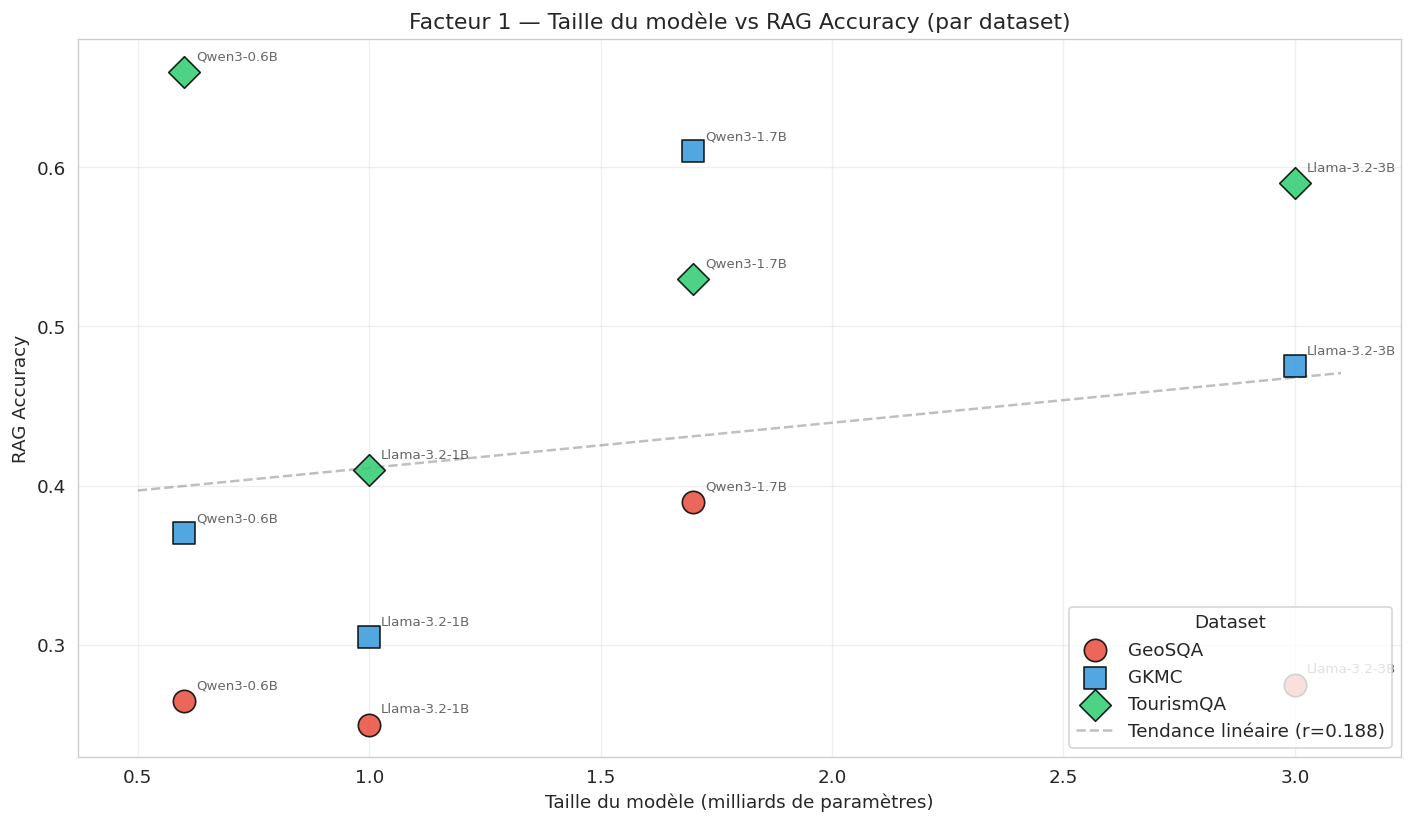

Figure sauvegardée : results/phase2d_fig1_taille_vs_accuracy.png

--- Interprétation ---
La tendance est positive mais la corrélation n’est pas significative.
D’autres facteurs (famille, type de tâche) semblent plus déterminants.


In [5]:
# === Analyse de l'effet de la taille du modèle ===============================
print('=' * 60)
print('FACTEUR 1 : Taille du modèle')
print('=' * 60)

# Moyennes par taille (tous datasets confondus)
size_means = df.groupby('Taille (B)').agg({
    'Baseline Acc': 'mean',
    'RAG Acc': 'mean',
    'Delta Acc': 'mean',
    'RAG F1': 'mean',
}).round(4)
print('\nMoyennes par taille (tous datasets) :')
print(size_means.to_string())

# Corrélation de Pearson : taille vs RAG Accuracy
corr_all, p_all = stats.pearsonr(df['Taille (B)'], df['RAG Acc'])
print(f'\nCorrélation (Pearson) Taille vs RAG Acc (tous datasets) : r={corr_all:.4f}, p={p_all:.4f}')

# Corrélation par dataset
print('\nCorrélation par dataset :')
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    if len(sub) >= 3:
        r, p = stats.pearsonr(sub['Taille (B)'], sub['RAG Acc'])
        sig = '(significatif)' if p < 0.05 else '(non significatif)'
        print(f'  {ds_name:12s} : r={r:.4f}, p={p:.4f} {sig}')

# --- Figure : Nuage de points Taille vs Accuracy par dataset -----------------
fig, ax = plt.subplots(figsize=(12, 7))

dataset_colors = {'GeoSQA': '#e74c3c', 'GKMC': '#3498db', 'TourismQA': '#2ecc71'}
dataset_markers = {'GeoSQA': 'o', 'GKMC': 's', 'TourismQA': 'D'}

for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    color = dataset_colors.get(ds_name, '#95a5a6')
    marker = dataset_markers.get(ds_name, 'o')
    ax.scatter(sub['Taille (B)'], sub['RAG Acc'], s=180, c=color,
               marker=marker, edgecolors='black', linewidth=1,
               label=ds_name, zorder=5, alpha=0.85)

    # Annoter chaque point avec le nom du modèle
    for _, row in sub.iterrows():
        ax.annotate(row['Modèle'], (row['Taille (B)'], row['RAG Acc']),
                    textcoords='offset points', xytext=(7, 7), fontsize=8,
                    alpha=0.7)

# Régression linéaire globale
sizes = np.asarray(df['Taille (B)'].values, dtype=float)
accs = np.asarray(df['RAG Acc'].values, dtype=float)
slope, intercept, _, _, _ = stats.linregress(sizes, accs)
x_line = np.linspace(sizes.min() - 0.1, sizes.max() + 0.1, 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='gray', alpha=0.5,
        label=f'Tendance linéaire (r={corr_all:.3f})')

ax.set_xlabel('Taille du modèle (milliards de paramètres)')
ax.set_ylabel('RAG Accuracy')
ax.set_title('Facteur 1 — Taille du modèle vs RAG Accuracy (par dataset)')
ax.legend(title='Dataset', loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig1_taille_vs_accuracy.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig1_taille_vs_accuracy.png')

# Interprétation
print('\n--- Interprétation ---')
if corr_all > 0.5 and p_all < 0.05:
    print('La taille du modèle est positivement et significativement corrélée')
    print('avec les performances RAG. Les modèles plus grands tendent à mieux performer.')
elif corr_all > 0:
    print('La tendance est positive mais la corrélation n’est pas significative.')
    print('D’autres facteurs (famille, type de tâche) semblent plus déterminants.')
else:
    print('Aucune corrélation positive claire entre taille et performance.')
    print('La taille seule ne suffit pas à expliquer les différences de performance.')

## Étape 3 — Analyse par facteur : Famille de modèle

Comparaison des familles de modèles (Qwen, Llama, Mistral) pour identifier
si certaines architectures sont mieux adaptées à certaines tâches géographiques.

FACTEUR 2 : Famille de modèle

Moyennes par famille (tous datasets) :
        RAG Acc          RAG F1         Baseline Acc Delta Acc Taille (B)
           mean     std    mean     std         mean      mean       mean
Famille                                                                  
Llama    0.3842  0.1323  0.1700  0.2621       0.4300   -0.0458       2.00
Qwen     0.4708  0.1534  0.2101  0.2983       0.4692    0.0017       1.15

Moyennes RAG Accuracy par Famille x Dataset :
Dataset  GKMC  GeoSQA  TourismQA
Famille                         
Llama    0.39  0.2625      0.500
Qwen     0.49  0.3275      0.595

Test t (2 familles) : t=1.0479, p=0.3193


/tmp/ipython-input-1885497076.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Famille', y='RAG Acc', palette=family_palette,


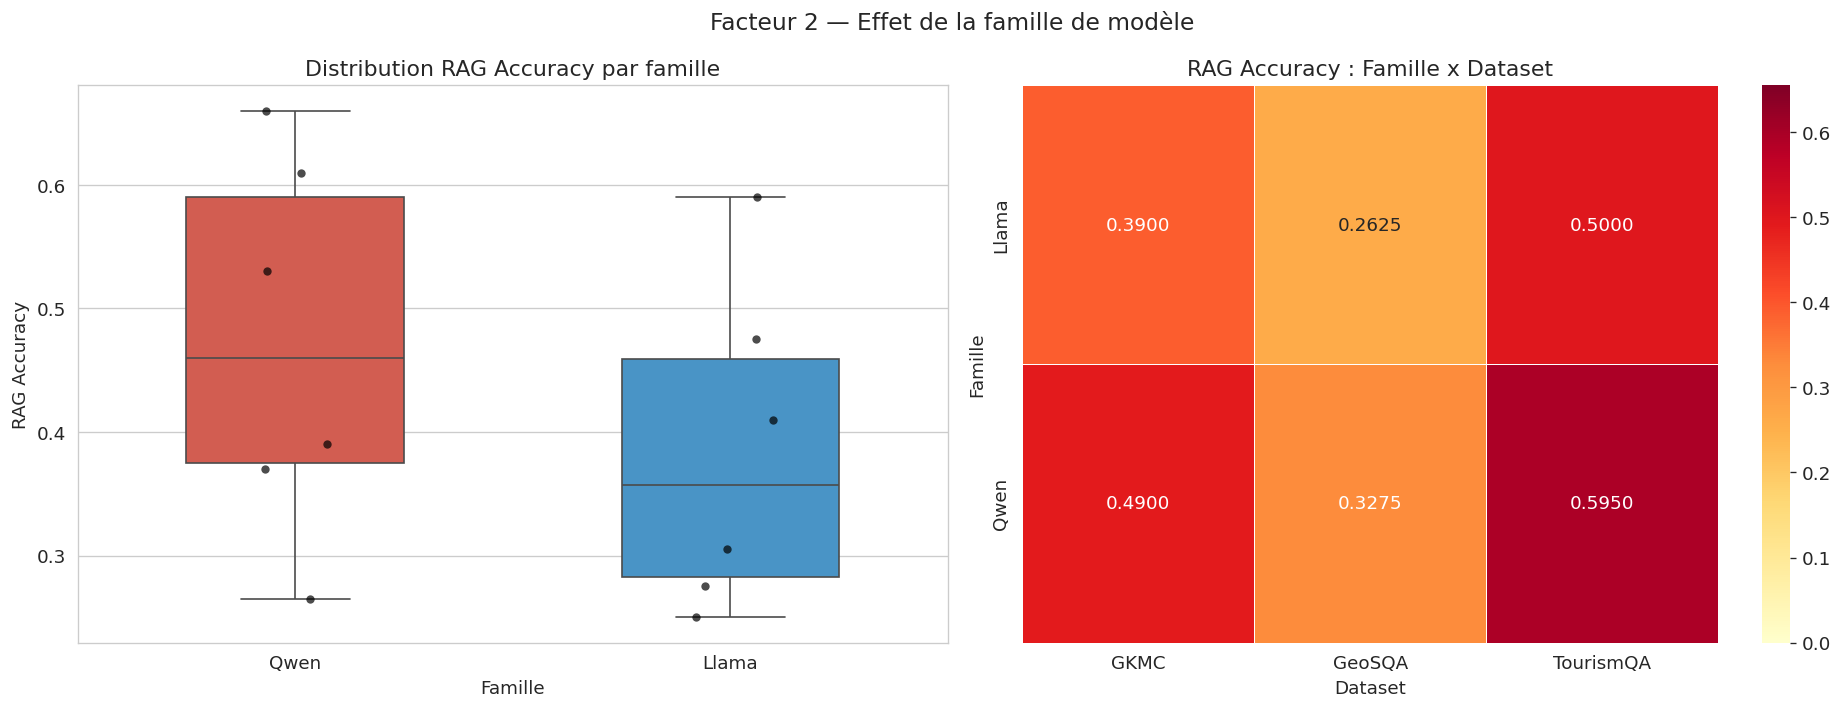

Figure sauvegardée : results/phase2d_fig2_famille_analyse.png

Meilleure famille (RAG Acc moyenne globale) : Qwen

Meilleure famille par dataset :
  GeoSQA       : Qwen (0.3275)
  GKMC         : Qwen (0.4900)
  TourismQA    : Qwen (0.5950)


In [6]:
# === Analyse de l'effet de la famille de modèle ==============================
print('=' * 60)
print('FACTEUR 2 : Famille de modèle')
print('=' * 60)

# Moyennes par famille (tous datasets confondus)
family_means = df.groupby('Famille').agg({
    'RAG Acc': ['mean', 'std'],
    'RAG F1': ['mean', 'std'],
    'Baseline Acc': 'mean',
    'Delta Acc': 'mean',
    'Taille (B)': 'mean',
}).round(4)
print('\nMoyennes par famille (tous datasets) :')
print(family_means.to_string())

# Moyennes par famille x dataset
print('\nMoyennes RAG Accuracy par Famille x Dataset :')
pivot_family = df.pivot_table(index='Famille', columns='Dataset',
                               values='RAG Acc', aggfunc='mean').round(4)
print(pivot_family.to_string())

# Test ANOVA (si >= 3 familles)
families = df['Famille'].unique()
if len(families) >= 2:
    groups = [df[df['Famille'] == f]['RAG Acc'].values for f in families]
    if all(len(g) >= 2 for g in groups):
        if len(families) >= 3:
            f_stat, p_val = stats.f_oneway(*groups)
            print(f'\nANOVA (Famille vs RAG Acc) : F={f_stat:.4f}, p={p_val:.4f}')
            if p_val < 0.05:
                print('  --> Différence significative entre familles (p < 0.05)')
            else:
                print('  --> Différence non significative (p >= 0.05)')
        else:
            t_stat, p_val = stats.ttest_ind(*groups)
            print(f'\nTest t (2 familles) : t={t_stat:.4f}, p={p_val:.4f}')

# --- Figure 1 : Box plots par famille ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot : RAG Accuracy par famille
family_palette = {'Qwen': '#e74c3c', 'Llama': '#3498db', 'Mistral': '#2ecc71'}
sns.boxplot(data=df, x='Famille', y='RAG Acc', palette=family_palette,
            ax=axes[0], width=0.5)
sns.stripplot(data=df, x='Famille', y='RAG Acc', color='black',
              ax=axes[0], size=5, alpha=0.7)
axes[0].set_title('Distribution RAG Accuracy par famille')
axes[0].set_ylabel('RAG Accuracy')

# Heatmap : Famille x Dataset
sns.heatmap(pivot_family, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], vmin=0,
            vmax=max(0.5, pivot_family.max().max() * 1.1))
axes[1].set_title('RAG Accuracy : Famille x Dataset')
axes[1].set_ylabel('Famille')
axes[1].set_xlabel('Dataset')

plt.suptitle('Facteur 2 — Effet de la famille de modèle', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig2_famille_analyse.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig2_famille_analyse.png')

# Meilleure famille
best_family_global = df.groupby('Famille')['RAG Acc'].mean().idxmax()
print(f'\nMeilleure famille (RAG Acc moyenne globale) : {best_family_global}')
print('\nMeilleure famille par dataset :')
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    best = sub.groupby('Famille')['RAG Acc'].mean().idxmax()
    val = sub.groupby('Famille')['RAG Acc'].mean().max()
    print(f'  {ds_name:12s} : {best} ({val:.4f})')

## Étape 4 — Analyse par facteur : Dataset (tâche)

Comparer la difficulté relative des trois benchmarks et identifier
les spécificités de chaque tâche (QCM vs recommandation).

FACTEUR 3 : Type de dataset

Moyennes par dataset :
           Baseline Acc  RAG Acc  Delta Acc  RAG F1  Temps RAG (s)
Dataset                                                           
GKMC             0.4738   0.4400    -0.0338  0.0147       700.0003
GeoSQA           0.2925   0.2950     0.0025  0.0095       605.0156
TourismQA        0.5825   0.5475    -0.0350  0.5459        91.9771

Classement de difficulté (du plus facile au plus difficile) :
  1. TourismQA    : RAG Acc moy = 0.5475
  2. GKMC         : RAG Acc moy = 0.4400
  3. GeoSQA       : RAG Acc moy = 0.2950


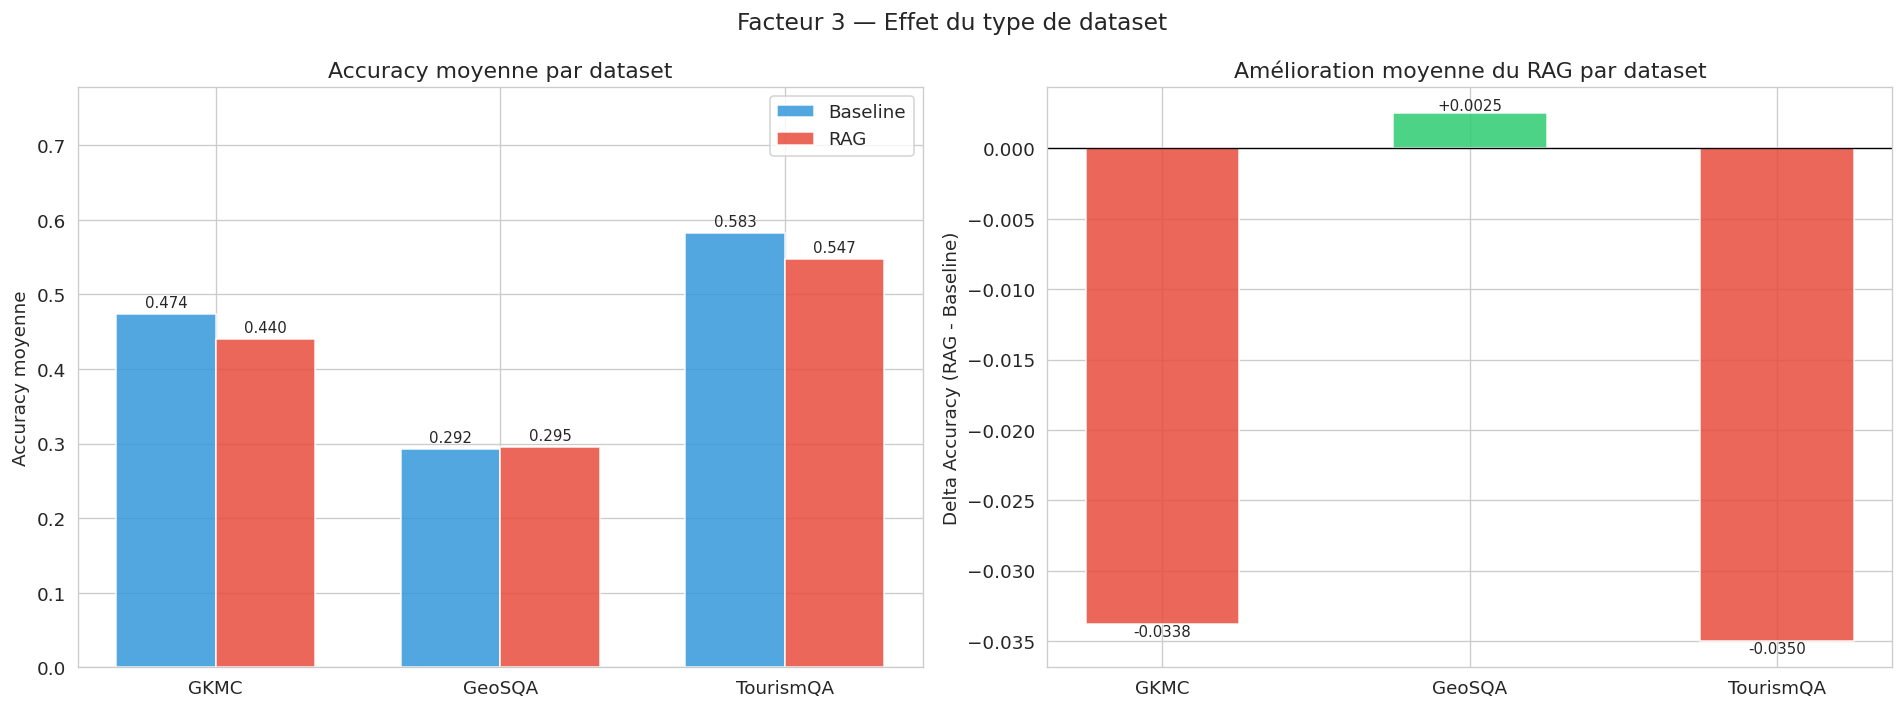

Figure sauvegardée : results/phase2d_fig3_dataset_analyse.png

--- Interprétation ---
Dataset le plus facile : TourismQA (RAG Acc moy = 0.5475)
Dataset le plus difficile : GeoSQA (RAG Acc moy = 0.2950)
Plus grand bénéfice RAG : GeoSQA (Delta = +0.0025)


In [7]:
# === Analyse de l'effet du dataset (type de tâche) ============================
print('=' * 60)
print('FACTEUR 3 : Type de dataset')
print('=' * 60)

# Moyennes par dataset
dataset_means = df.groupby('Dataset').agg({
    'Baseline Acc': 'mean',
    'RAG Acc': 'mean',
    'Delta Acc': 'mean',
    'RAG F1': 'mean',
    'Temps RAG (s)': 'mean',
}).round(4)
print('\nMoyennes par dataset :')
print(dataset_means.to_string())

# Classement de difficulté
print('\nClassement de difficulté (du plus facile au plus difficile) :')
for rank, (ds_name, row) in enumerate(
    dataset_means.sort_values('RAG Acc', ascending=False).iterrows(), 1
):
    print(f'  {rank}. {ds_name:12s} : RAG Acc moy = {row["RAG Acc"]:.4f}')

# --- Figure : Accuracy par dataset (barres) ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barres : Baseline vs RAG par dataset
x = np.arange(len(dataset_means))
width = 0.35
ds_names = dataset_means.index.tolist()

bars1 = axes[0].bar(x - width/2, dataset_means['Baseline Acc'], width,
                     label='Baseline', color='#3498db', alpha=0.85)
bars2 = axes[0].bar(x + width/2, dataset_means['RAG Acc'], width,
                     label='RAG', color='#e74c3c', alpha=0.85)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.005,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(ds_names)
axes[0].set_ylabel('Accuracy moyenne')
axes[0].set_title('Accuracy moyenne par dataset')
axes[0].legend()
axes[0].set_ylim(0, max(dataset_means['RAG Acc'].max(), dataset_means['Baseline Acc'].max()) * 1.25 + 0.05)

# Barres : Delta (amélioration RAG) par dataset
deltas = np.asarray(dataset_means['Delta Acc'].values, dtype=float)
colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
bars3 = axes[1].bar(x, deltas, 0.5, color=colors, alpha=0.85, edgecolor='white')
for bar in bars3:
    h = bar.get_height()
    va = 'bottom' if h >= 0 else 'top'
    axes[1].text(bar.get_x() + bar.get_width()/2., h,
                 f'{h:+.4f}', ha='center', va=va, fontsize=9)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ds_names)
axes[1].set_ylabel('Delta Accuracy (RAG - Baseline)')
axes[1].set_title('Amélioration moyenne du RAG par dataset')

plt.suptitle('Facteur 3 — Effet du type de dataset', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig3_dataset_analyse.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig3_dataset_analyse.png')

# Interprétation
easiest = dataset_means['RAG Acc'].idxmax()
hardest = dataset_means['RAG Acc'].idxmin()
best_rag_ds = dataset_means['Delta Acc'].idxmax()
print(f'\n--- Interprétation ---')
print(f'Dataset le plus facile : {easiest} (RAG Acc moy = {dataset_means.loc[easiest, "RAG Acc"]:.4f})')
print(f'Dataset le plus difficile : {hardest} (RAG Acc moy = {dataset_means.loc[hardest, "RAG Acc"]:.4f})')
print(f'Plus grand bénéfice RAG : {best_rag_ds} (Delta = {dataset_means.loc[best_rag_ds, "Delta Acc"]:+.4f})')

## Étape 5 — Analyse par facteur : Impact du RAG

Analyse détaillée de l’amélioration (ou dégradation) apportée par le RAG
en fonction du modèle et du dataset. Quand le RAG aide-t-il le plus ?

FACTEUR 4 : Impact du RAG

Delta Accuracy (RAG - Baseline) par Modèle x Dataset :
Dataset        GKMC  GeoSQA  TourismQA
Modèle                                
Llama-3.2-1B -0.095   0.040      -0.03
Llama-3.2-3B -0.045  -0.025      -0.12
Qwen3-0.6B   -0.015  -0.005       0.06
Qwen3-1.7B    0.020   0.000      -0.05

Résumé de l’impact du RAG :
  Cas positifs (delta > +0.02) : 3/12 (25.0%)
  Cas neutres  (|delta| <= 0.02) : 3/12 (25.0%)
  Cas négatifs (delta < -0.02) : 6/12 (50.0%)
  Impact moyen : -0.0221

Test t apparié (RAG vs Baseline) : t=-1.4779, p=0.1675
  --> Différence non significative (p >= 0.05)


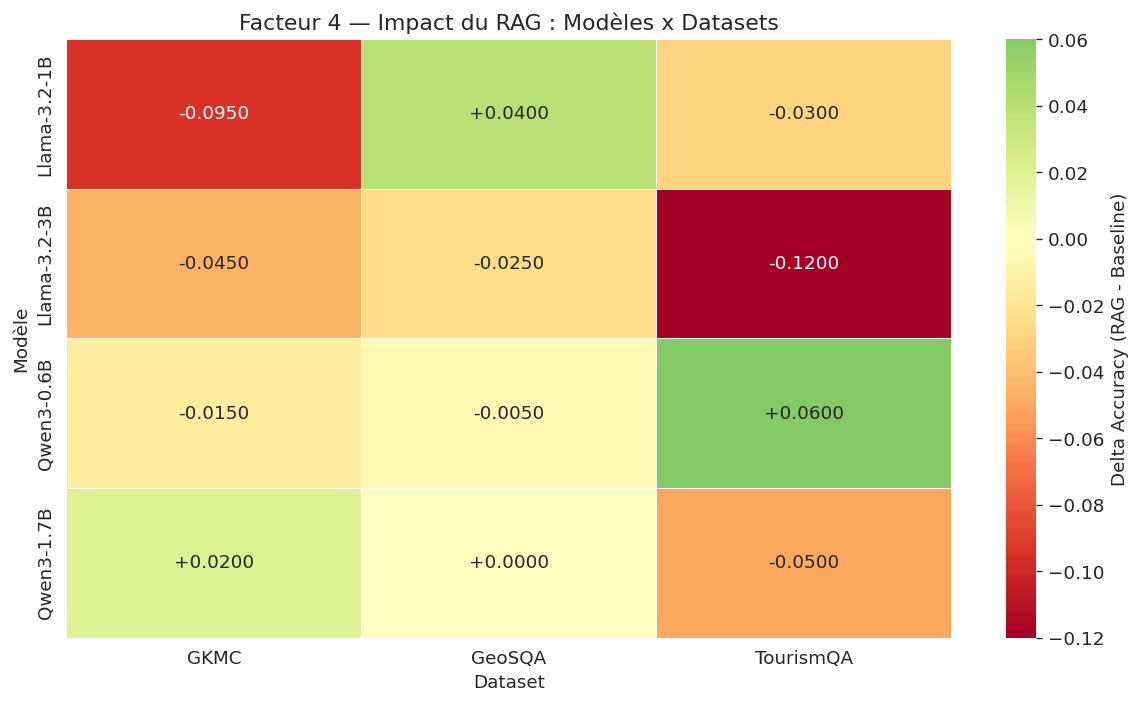

Figure sauvegardée : results/phase2d_fig4_impact_rag_heatmap.png

Détail par modèle :
  Qwen3-0.6B           : moy=+0.0133 (NEUTRE) [-0.0050, -0.0150, +0.0600]
  Qwen3-1.7B           : moy=-0.0100 (NEUTRE) [+0.0000, +0.0200, -0.0500]
  Llama-3.2-1B         : moy=-0.0283 (NÉGATIF) [+0.0400, -0.0950, -0.0300]
  Llama-3.2-3B         : moy=-0.0633 (NÉGATIF) [-0.0250, -0.0450, -0.1200]


In [8]:
# === Analyse de l'impact du RAG ================================================
print('=' * 60)
print('FACTEUR 4 : Impact du RAG')
print('=' * 60)

# Pivot table : Delta Accuracy par Modèle x Dataset
pivot_delta = df.pivot_table(index='Modèle', columns='Dataset',
                              values='Delta Acc', aggfunc='mean').round(4)
print('\nDelta Accuracy (RAG - Baseline) par Modèle x Dataset :')
print(pivot_delta.to_string())

# Résumé de l'impact
print('\nRésumé de l’impact du RAG :')
n_total = len(df)
n_positive = (df['Delta Acc'] > 0.02).sum()
n_negative = (df['Delta Acc'] < -0.02).sum()
n_neutre = n_total - n_positive - n_negative
print(f'  Cas positifs (delta > +0.02) : {n_positive}/{n_total} ({n_positive/n_total*100:.1f}%)')
print(f'  Cas neutres  (|delta| <= 0.02) : {n_neutre}/{n_total} ({n_neutre/n_total*100:.1f}%)')
print(f'  Cas négatifs (delta < -0.02) : {n_negative}/{n_total} ({n_negative/n_total*100:.1f}%)')
print(f'  Impact moyen : {df["Delta Acc"].mean():+.4f}')

# Test statistique : le RAG améliore-t-il significativement les performances ?
t_stat, p_val = stats.ttest_rel(df['RAG Acc'], df['Baseline Acc'])
print(f'\nTest t apparié (RAG vs Baseline) : t={t_stat:.4f}, p={p_val:.4f}')
if p_val < 0.05:
    direction = 'améliore' if t_stat > 0 else 'dégrade'
    print(f'  --> Le RAG {direction} significativement les performances (p < 0.05)')
else:
    print('  --> Différence non significative (p >= 0.05)')

# --- Heatmap : Delta Accuracy Modèles x Datasets ----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Annoter avec couleurs divergentes (vert = positif, rouge = négatif)
sns.heatmap(pivot_delta, annot=True, fmt='+.4f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Delta Accuracy (RAG - Baseline)'})
ax.set_title('Facteur 4 — Impact du RAG : Modèles x Datasets')
ax.set_ylabel('Modèle')
ax.set_xlabel('Dataset')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig4_impact_rag_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig4_impact_rag_heatmap.png')

# Détail par modèle
print('\nDétail par modèle :')
for model_name in df['Modèle'].unique():
    sub = df[df['Modèle'] == model_name]
    avg_delta = sub['Delta Acc'].mean()
    if avg_delta > 0.02:
        impact = 'POSITIF'
    elif avg_delta < -0.02:
        impact = 'NÉGATIF'
    else:
        impact = 'NEUTRE'
    deltas_str = ', '.join(f'{d:+.4f}' for d in sub['Delta Acc'].values)
    print(f'  {model_name:20s} : moy={avg_delta:+.4f} ({impact}) [{deltas_str}]')

## Étape 6 — Analyse multifactorielle

Croiser les facteurs (taille, famille, dataset) pour identifier les meilleures
configurations et construire un classement global.

ANALYSE MULTIFACTORIELLE

Meilleur modèle par dataset (RAG Accuracy) :
  GeoSQA       : Qwen3-1.7B           (RAG Acc=0.3900, Famille=Qwen, Taille=1.7B)
  GKMC         : Qwen3-1.7B           (RAG Acc=0.6100, Famille=Qwen, Taille=1.7B)
  TourismQA    : Qwen3-0.6B           (RAG Acc=0.6600, Famille=Qwen, Taille=0.6B)

Classement global (moyenne des RAG Accuracy sur tous les datasets) :
  1. Qwen3-1.7B           | RAG Acc=0.5100 | F1=0.1904 | Delta=-0.0100 | Qwen 1.7B
  2. Llama-3.2-3B         | RAG Acc=0.4467 | F1=0.2016 | Delta=-0.0633 | Llama 3.0B
  3. Qwen3-0.6B           | RAG Acc=0.4317 | F1=0.2298 | Delta=+0.0133 | Qwen 0.6B
  4. Llama-3.2-1B         | RAG Acc=0.3217 | F1=0.1383 | Delta=-0.0283 | Llama 1.0B

Meilleur modèle global : Qwen3-1.7B

Efficacité (RAG Acc moyenne / Taille) :
  Qwen3-0.6B           : Eff=0.7195 (Acc=0.4317 / 0.6B)
  Llama-3.2-1B         : Eff=0.3217 (Acc=0.3217 / 1.0B)
  Qwen3-1.7B           : Eff=0.3000 (Acc=0.5100 / 1.7B)
  Llama-3.2-3B         : Eff=0.14

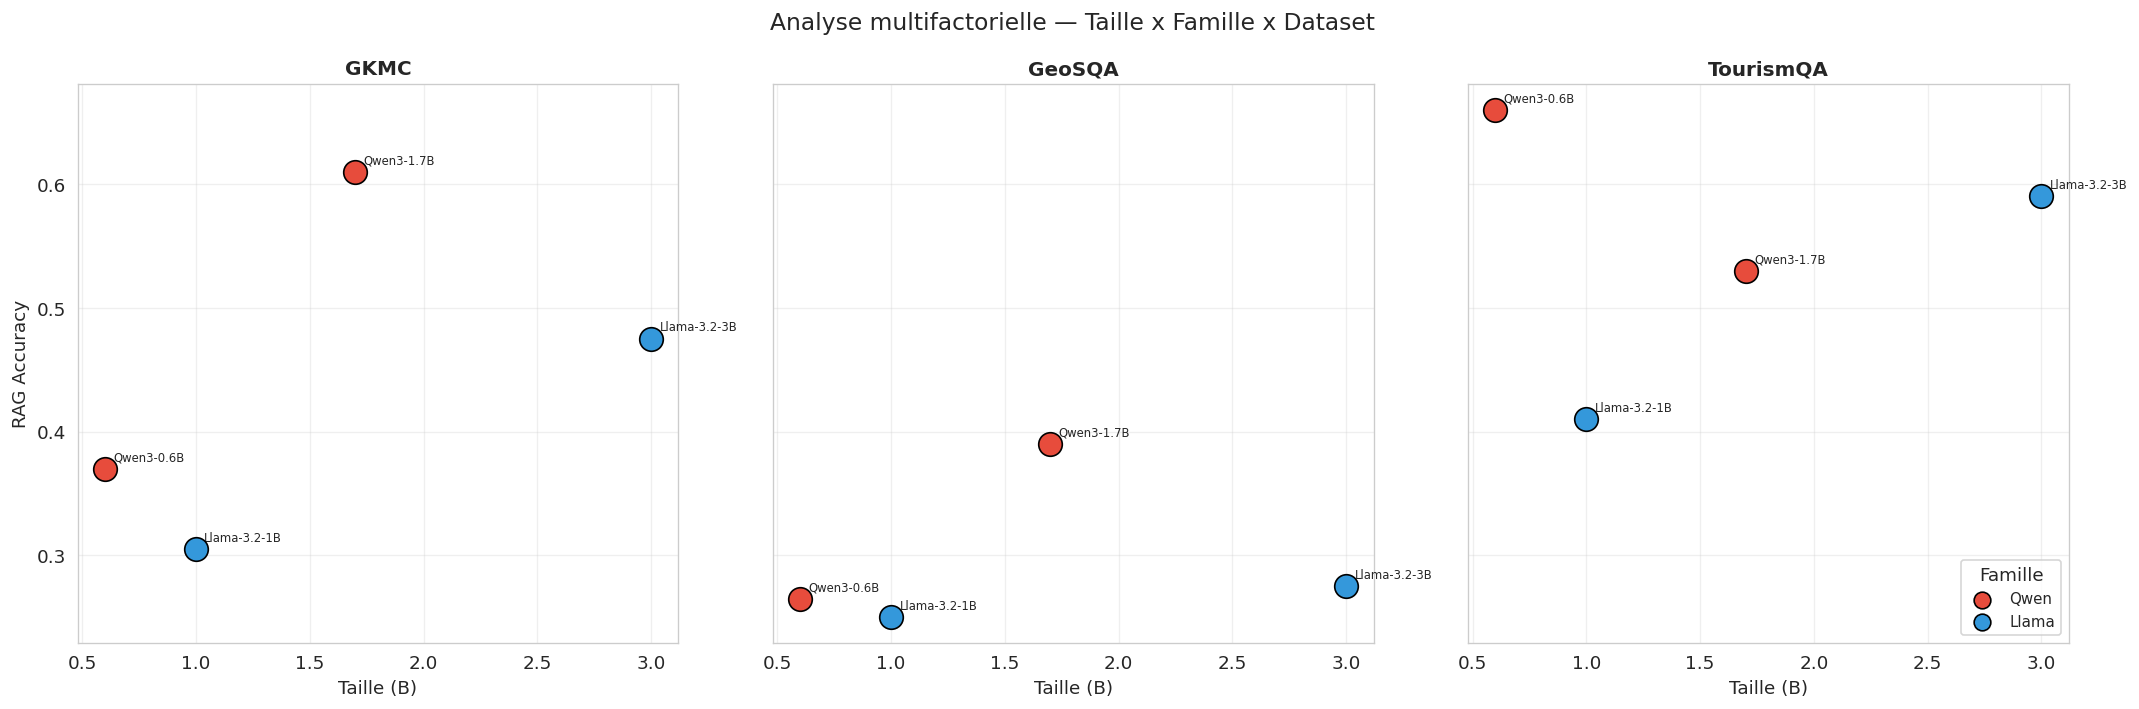

Figure sauvegardée : results/phase2d_fig5_multifactorielle.png


In [9]:
# === Analyse multifactorielle =================================================
print('=' * 60)
print('ANALYSE MULTIFACTORIELLE')
print('=' * 60)

# --- Meilleure configuration par dataset -------------------------------------
print('\nMeilleur modèle par dataset (RAG Accuracy) :')
best_per_dataset = {}
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    best_idx = sub['RAG Acc'].idxmax()
    best_row = sub.loc[best_idx]
    best_per_dataset[ds_name] = best_row['Modèle']
    print(f'  {ds_name:12s} : {best_row["Modèle"]:20s} '
          f'(RAG Acc={best_row["RAG Acc"]:.4f}, Famille={best_row["Famille"]}, '
          f'Taille={best_row["Taille (B)"]:.1f}B)')

# --- Classement global (moyenne rangée sur tous les datasets) ----------------
print('\nClassement global (moyenne des RAG Accuracy sur tous les datasets) :')
ranking = df.groupby('Modèle').agg({
    'RAG Acc': 'mean',
    'RAG F1': 'mean',
    'Delta Acc': 'mean',
    'Taille (B)': 'first',
    'Famille': 'first',
}).round(4)
ranking = ranking.sort_values('RAG Acc', ascending=False)
for rank, (model_name, row) in enumerate(ranking.iterrows(), 1):
    print(f'  {rank}. {model_name:20s} | RAG Acc={row["RAG Acc"]:.4f} | '
          f'F1={row["RAG F1"]:.4f} | Delta={row["Delta Acc"]:+.4f} | '
          f'{row["Famille"]} {row["Taille (B)"]:.1f}B')

best_model_overall = ranking.index[0]
print(f'\nMeilleur modèle global : {best_model_overall}')

# --- Métrique d'efficacité : Accuracy / Taille ------------------------------
print('\nEfficacité (RAG Acc moyenne / Taille) :')
ranking['Efficacité'] = ranking['RAG Acc'] / ranking['Taille (B)']
for _, (model_name, row) in enumerate(
    ranking.sort_values('Efficacité', ascending=False).iterrows()
):
    print(f'  {model_name:20s} : Eff={row["Efficacité"]:.4f} '
          f'(Acc={row["RAG Acc"]:.4f} / {row["Taille (B)"]:.1f}B)')

# --- Métrique de robustesse : écart-type entre datasets ---------------------
print('\nRobustesse (écart-type RAG Acc entre datasets) :')
robustness = df.groupby('Modèle')['RAG Acc'].std().round(4)
for model_name in ranking.index:
    std_val = robustness.get(model_name, 0)
    print(f'  {model_name:20s} : σ = {std_val:.4f}')

# --- Graphique facetté : Taille x Famille x Dataset --------------------------
fig, axes = plt.subplots(1, len(df['Dataset'].unique()), figsize=(18, 6),
                          sharey=True)
if len(df['Dataset'].unique()) == 1:
    axes = [axes]

family_colors = {'Qwen': '#e74c3c', 'Llama': '#3498db', 'Mistral': '#2ecc71'}

for ax_i, ds_name in zip(axes, sorted(df['Dataset'].unique())):
    sub = df[df['Dataset'] == ds_name]
    for _, row in sub.iterrows():
        color = family_colors.get(row['Famille'], '#95a5a6')
        ax_i.scatter(row['Taille (B)'], row['RAG Acc'], s=200, c=color,
                     edgecolors='black', linewidth=1, zorder=5)
        ax_i.annotate(row['Modèle'], (row['Taille (B)'], row['RAG Acc']),
                      textcoords='offset points', xytext=(5, 5), fontsize=7)
    ax_i.set_title(ds_name, fontsize=12, fontweight='bold')
    ax_i.set_xlabel('Taille (B)')
    ax_i.grid(True, alpha=0.3)

axes[0].set_ylabel('RAG Accuracy')

# Légende commune
for family, color in family_colors.items():
    if family in df['Famille'].values:
        axes[-1].scatter([], [], c=color, s=100, edgecolors='black',
                         linewidth=1, label=family)
axes[-1].legend(title='Famille', loc='lower right', fontsize=9)

plt.suptitle('Analyse multifactorielle — Taille x Famille x Dataset', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig5_multifactorielle.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig5_multifactorielle.png')

## Étape 7 — Visualisations de synthèse

Quatre figures récapitulatives pour une vue d’ensemble complète :
1. **Grande heatmap** : Modèles x (Dataset x Métrique)
2. **Diagramme radar** par modèle (métriques normalisées)
3. **Front de Pareto** : Accuracy vs Latence
4. **Classement final** : barre horizontale avec scores globaux

--- Figure 6 : Grande heatmap ---


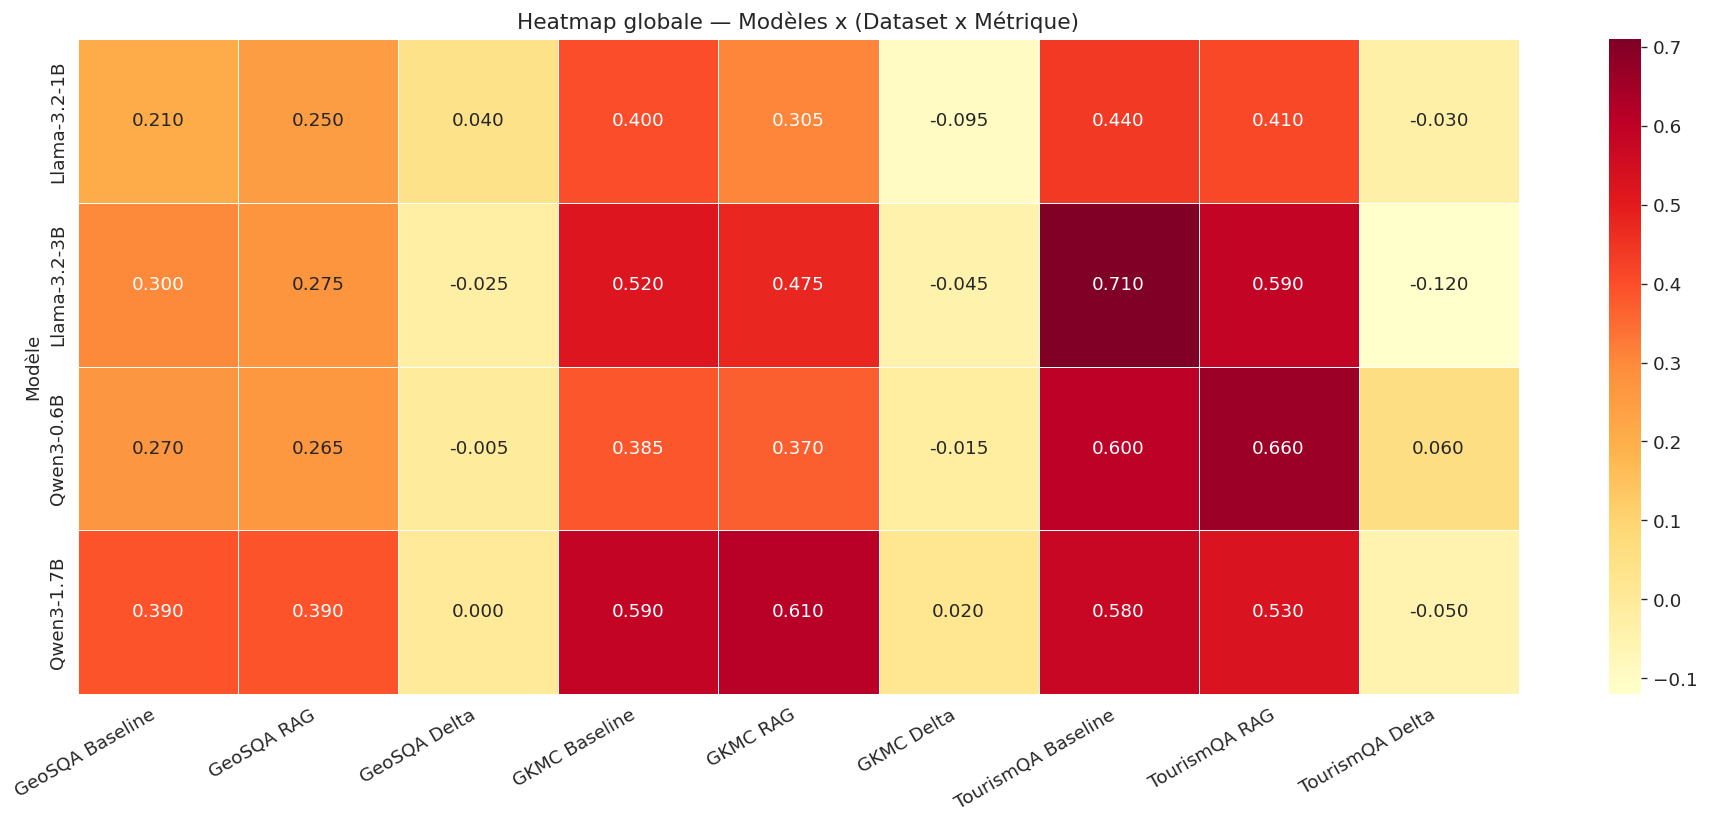

Figure sauvegardée : results/phase2d_fig6_grande_heatmap.png

--- Figure 7 : Diagramme radar ---


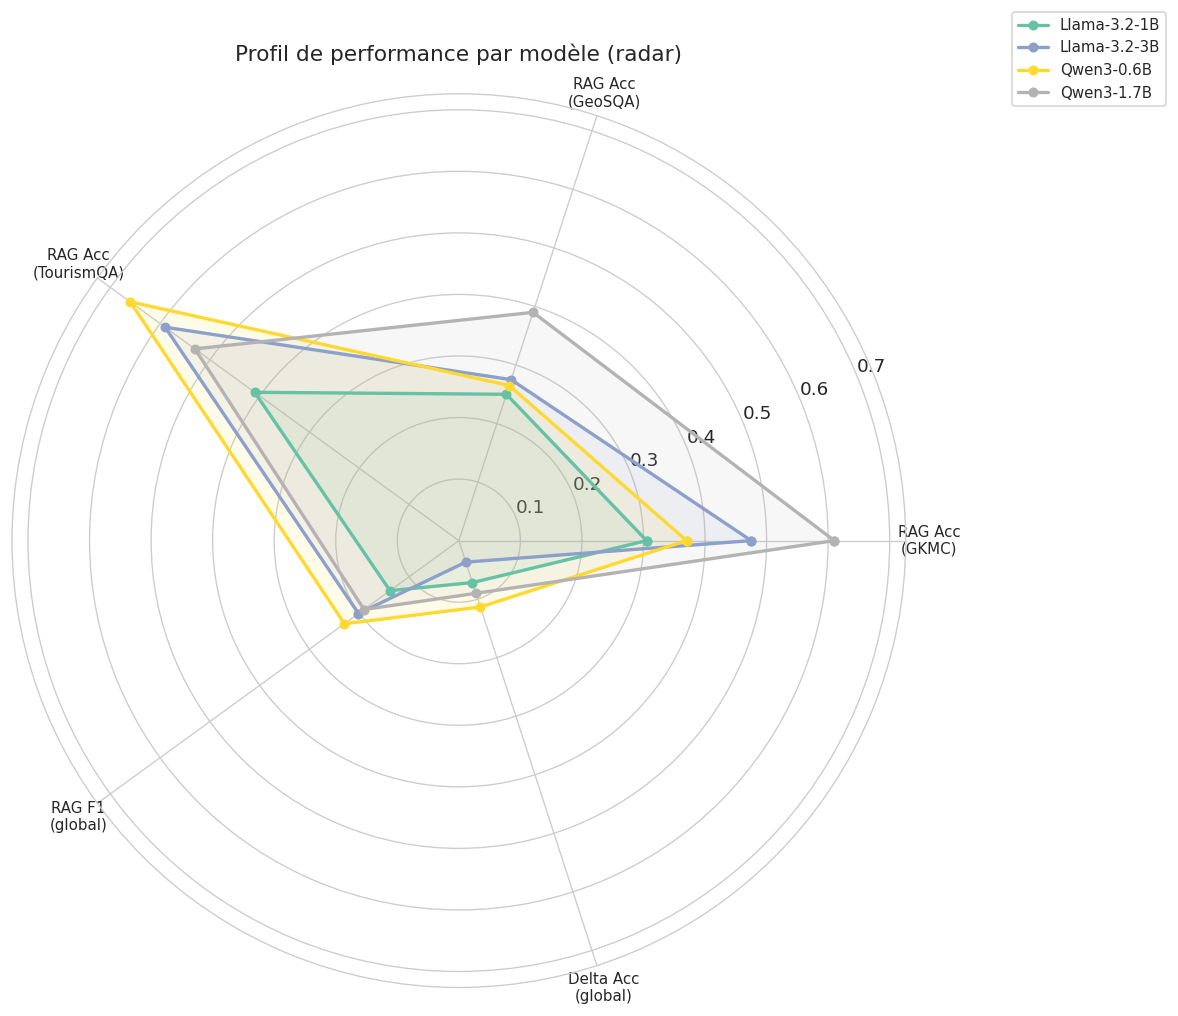

Figure sauvegardée : results/phase2d_fig7_radar.png

--- Figure 8 : Front de Pareto ---


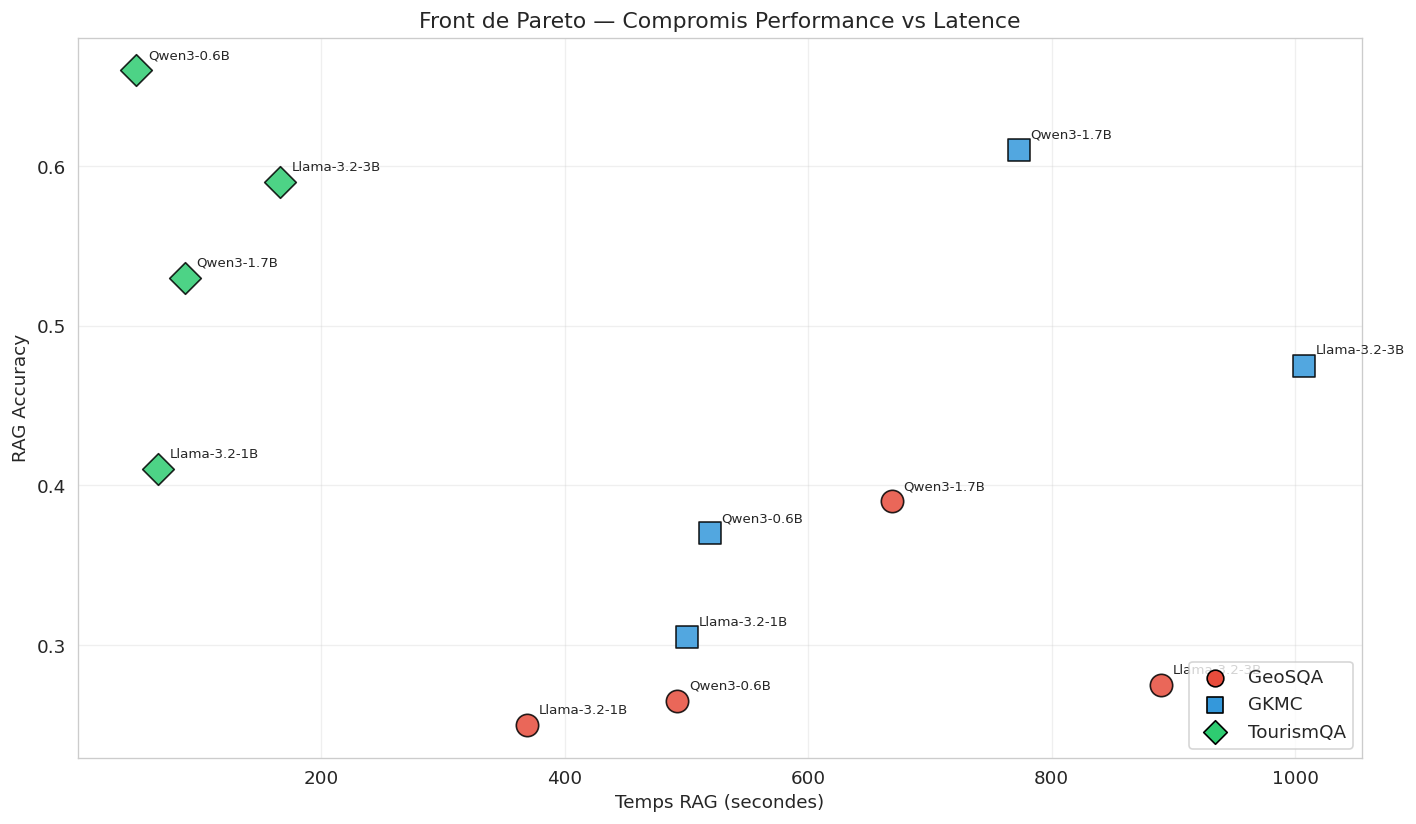

Figure sauvegardée : results/phase2d_fig8_pareto.png

--- Figure 9 : Classement final ---


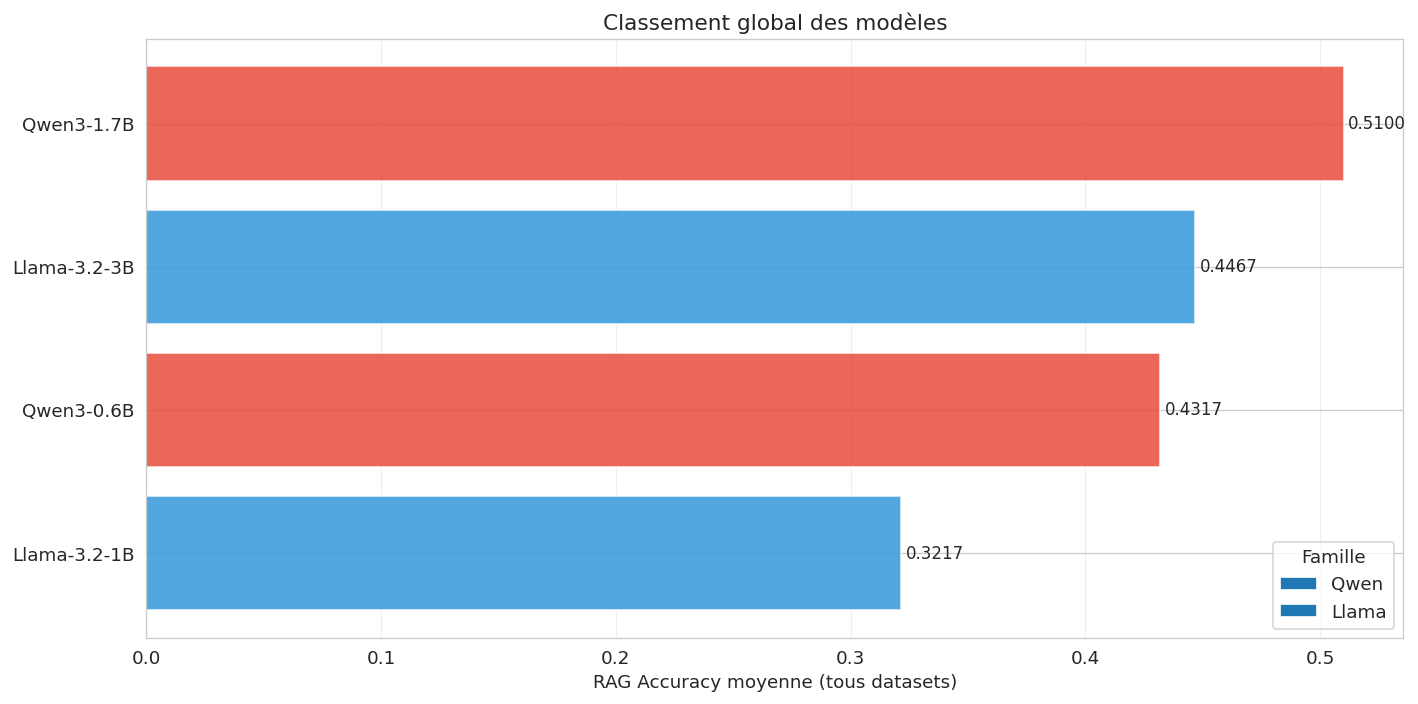

Figure sauvegardée : results/phase2d_fig9_classement_final.png


In [10]:
# === Visualisations de synthèse ===============================================

# ======================================================================
# Figure 6 : Grande heatmap — Modèles x (Dataset x Métrique)
# ======================================================================
print('--- Figure 6 : Grande heatmap ---')

# Construire une matrice large
heatmap_rows = []
for _, row in df.iterrows():
    heatmap_rows.append({
        'Modèle': row['Modèle'],
        f'{row["Dataset"]} Baseline': row['Baseline Acc'],
        f'{row["Dataset"]} RAG': row['RAG Acc'],
        f'{row["Dataset"]} Delta': row['Delta Acc'],
    })

# Agréger par modèle (au cas où plusieurs lignes par modèle)
df_heatmap = pd.DataFrame(heatmap_rows)
df_heatmap = df_heatmap.groupby('Modèle').first().reset_index()

# Réorganiser pour avoir toutes les colonnes
pivot_cols = [c for c in df_heatmap.columns if c != 'Modèle']
df_heatmap = df_heatmap.set_index('Modèle')[pivot_cols]

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Heatmap globale — Modèles x (Dataset x Métrique)', fontsize=13)
ax.set_ylabel('Modèle')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig6_grande_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig6_grande_heatmap.png')

# ======================================================================
# Figure 7 : Diagramme radar par modèle
# ======================================================================
print('\n--- Figure 7 : Diagramme radar ---')

# Métriques pour le radar : moyenne RAG Acc par dataset + F1 + Delta
radar_metrics = []
radar_labels = []
for ds_name in sorted(df['Dataset'].unique()):
    radar_labels.append(f'RAG Acc\n({ds_name})')
    radar_metrics.append(('RAG Acc', ds_name))
radar_labels.append('RAG F1\n(global)')
radar_metrics.append(('RAG F1', None))
radar_labels.append('Delta Acc\n(global)')
radar_metrics.append(('Delta Acc', None))

model_names = sorted(df['Modèle'].unique())
n_metrics = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # fermer le polygone

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

model_colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

for m_idx, model_name in enumerate(model_names):
    values = []
    for metric, ds in radar_metrics:
        if ds:
            sub = df[(df['Modèle'] == model_name) & (df['Dataset'] == ds)]
            val = sub[metric].values[0] if len(sub) > 0 else 0
        else:
            sub = df[df['Modèle'] == model_name]
            val = sub[metric].mean() if len(sub) > 0 else 0
        values.append(val)

    # Normaliser les valeurs (0-1) pour le radar
    # Delta peut être négatif, on le recentre
    values_plot = values.copy()
    values_plot[-1] = max(0, values_plot[-1] + 0.1)  # décaler le delta pour visibilité
    values_plot = [max(0, min(1, v)) for v in values_plot]  # clip 0-1
    values_plot += values_plot[:1]  # fermer

    ax.plot(angles, values_plot, 'o-', linewidth=2, color=model_colors[m_idx],
            label=model_name, markersize=5)
    ax.fill(angles, values_plot, alpha=0.1, color=model_colors[m_idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_ylim(0, max(0.6, df['RAG Acc'].max() * 1.1))
ax.set_title('Profil de performance par modèle (radar)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig7_radar.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig7_radar.png')

# ======================================================================
# Figure 8 : Front de Pareto — Accuracy vs Latence
# ======================================================================
print('\n--- Figure 8 : Front de Pareto ---')

fig, ax = plt.subplots(figsize=(12, 7))

for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    color = dataset_colors.get(ds_name, '#95a5a6')
    marker = dataset_markers.get(ds_name, 'o')

    for _, row in sub.iterrows():
        ax.scatter(row['Temps RAG (s)'], row['RAG Acc'], s=180,
                   c=color, marker=marker, edgecolors='black',
                   linewidth=1, zorder=5, alpha=0.85)
        ax.annotate(row['Modèle'], (row['Temps RAG (s)'], row['RAG Acc']),
                    textcoords='offset points', xytext=(7, 7), fontsize=8)

# Légende datasets
for ds_name in df['Dataset'].unique():
    color = dataset_colors.get(ds_name, '#95a5a6')
    marker = dataset_markers.get(ds_name, 'o')
    ax.scatter([], [], c=color, marker=marker, s=100,
               edgecolors='black', linewidth=1, label=ds_name)

# Identifier le front de Pareto (approximation)
all_times = np.asarray(df['Temps RAG (s)'].values, dtype=float)
all_accs = np.asarray(df['RAG Acc'].values, dtype=float)
# Trier par temps croissant et garder les non-dominés
sorted_idx = np.argsort(all_times)
pareto_times = []
pareto_accs = []
max_acc = -1
for i in sorted_idx:
    if all_accs[i] > max_acc:
        pareto_times.append(all_times[i])
        pareto_accs.append(all_accs[i])
        max_acc = all_accs[i]

if len(pareto_times) >= 2:
    ax.plot(pareto_times, pareto_accs, '--', color='orange', alpha=0.7,
            linewidth=2, label='Front de Pareto', zorder=1)

ax.set_xlabel('Temps RAG (secondes)')
ax.set_ylabel('RAG Accuracy')
ax.set_title('Front de Pareto — Compromis Performance vs Latence')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig8_pareto.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig8_pareto.png')

# ======================================================================
# Figure 9 : Classement final (barres horizontales)
# ======================================================================
print('\n--- Figure 9 : Classement final ---')

fig, ax = plt.subplots(figsize=(12, 6))

# Score global = moyenne RAG Acc sur tous les datasets
global_scores = df.groupby('Modèle')['RAG Acc'].mean().sort_values(ascending=True)
colors_bar = [family_colors.get(
    df[df['Modèle'] == m]['Famille'].values[0], '#95a5a6'
) for m in global_scores.index]

bars = ax.barh(range(len(global_scores)), global_scores.values,
               color=colors_bar, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(global_scores)))
ax.set_yticklabels(global_scores.index, fontsize=11)

for i, (score, model_name) in enumerate(zip(global_scores.values, global_scores.index)):
    ax.text(score + 0.002, i, f'{score:.4f}', va='center', fontsize=10)

# Légende familles
for family, color in family_colors.items():
    if family in df['Famille'].values:
        ax.barh([], [], color=color, label=family)
ax.legend(title='Famille', loc='lower right')

ax.set_xlabel('RAG Accuracy moyenne (tous datasets)')
ax.set_title('Classement global des modèles', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig9_classement_final.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig9_classement_final.png')

## Étape 8 — Sauvegarde des résultats

In [11]:
# === Sauvegarde des résultats unifiés ========================================

# 1. CSV unifié
csv_path = f'{RESULTS_DIR}/phase2d_unified_results.csv'
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'DataFrame unifié sauvegardé : {csv_path}')

# 2. Résumé JSON
# Classement global
global_ranking = df.groupby('Modèle')['RAG Acc'].mean().sort_values(ascending=False)
best_model_overall = global_ranking.index[0]
best_model_score = float(global_ranking.values[0])

# Meilleur par dataset
best_per_dataset = {}
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    best_idx = sub['RAG Acc'].idxmax()
    best_per_dataset[ds_name] = {
        'model': sub.loc[best_idx, 'Modèle'],
        'rag_accuracy': float(sub.loc[best_idx, 'RAG Acc']),
        'family': sub.loc[best_idx, 'Famille'],
    }

# Impact RAG
rag_impact = {
    'mean_delta': float(df['Delta Acc'].mean()),
    'n_positive': int((df['Delta Acc'] > 0.02).sum()),
    'n_neutral': int(((df['Delta Acc'] >= -0.02) & (df['Delta Acc'] <= 0.02)).sum()),
    'n_negative': int((df['Delta Acc'] < -0.02).sum()),
    'total': len(df),
}

# Corrélation taille
size_corr_r, size_corr_p = stats.pearsonr(df['Taille (B)'], df['RAG Acc'])

summary = {
    'phase': '2d',
    'description': 'Analyse factorielle croisée des Phases 2a, 2b et 2c',
    'n_datasets': len(df['Dataset'].unique()),
    'n_models': len(df['Modèle'].unique()),
    'n_total_evaluations': len(df),
    'best_model_overall': {
        'name': best_model_overall,
        'mean_rag_accuracy': best_model_score,
    },
    'best_model_per_dataset': best_per_dataset,
    'rag_impact_summary': rag_impact,
    'size_correlation': {
        'pearson_r': float(size_corr_r),
        'p_value': float(size_corr_p),
        'significant': bool(size_corr_p < 0.05),
    },
    'ranking': [
        {'rank': i+1, 'model': name, 'mean_rag_accuracy': float(score)}
        for i, (name, score) in enumerate(global_ranking.items())
    ],
}

json_path = f'{RESULTS_DIR}/phase2d_analysis_summary.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'Résumé JSON sauvegardé : {json_path}')

# 3. Liste des fichiers générés
print(f'\n{"=" * 60}')
print('FICHIERS GÉNÉRÉS')
print(f'{"=" * 60}')
generated_files = [
    csv_path,
    json_path,
    f'{RESULTS_DIR}/phase2d_fig1_taille_vs_accuracy.png',
    f'{RESULTS_DIR}/phase2d_fig2_famille_analyse.png',
    f'{RESULTS_DIR}/phase2d_fig3_dataset_analyse.png',
    f'{RESULTS_DIR}/phase2d_fig4_impact_rag_heatmap.png',
    f'{RESULTS_DIR}/phase2d_fig5_multifactorielle.png',
    f'{RESULTS_DIR}/phase2d_fig6_grande_heatmap.png',
    f'{RESULTS_DIR}/phase2d_fig7_radar.png',
    f'{RESULTS_DIR}/phase2d_fig8_pareto.png',
    f'{RESULTS_DIR}/phase2d_fig9_classement_final.png',
]
for fpath in generated_files:
    print(f'  {fpath}')

# 4. Sauvegarde optionnelle sur Google Drive
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_dest = '/content/drive/MyDrive/GeoR2LLMs/Phase2d/results'
        os.makedirs(drive_dest, exist_ok=True)

        for fname in os.listdir(RESULTS_DIR):
            if fname.startswith('phase2d_'):
                src = os.path.join(RESULTS_DIR, fname)
                dst = os.path.join(drive_dest, fname)
                shutil.copy2(src, dst)
                print(f'Copie : {dst}')

        print(f'\nRésultats copiés sur Google Drive : {drive_dest}')

    except ImportError:
        print('\nGoogle Drive non disponible (environnement non-Colab).')
    except Exception as e:
        print(f'\nErreur lors de la sauvegarde sur Google Drive : {e}')

DataFrame unifié sauvegardé : results/phase2d_unified_results.csv
Résumé JSON sauvegardé : results/phase2d_analysis_summary.json

FICHIERS GÉNÉRÉS
  results/phase2d_unified_results.csv
  results/phase2d_analysis_summary.json
  results/phase2d_fig1_taille_vs_accuracy.png
  results/phase2d_fig2_famille_analyse.png
  results/phase2d_fig3_dataset_analyse.png
  results/phase2d_fig4_impact_rag_heatmap.png
  results/phase2d_fig5_multifactorielle.png
  results/phase2d_fig6_grande_heatmap.png
  results/phase2d_fig7_radar.png
  results/phase2d_fig8_pareto.png
  results/phase2d_fig9_classement_final.png
Mounted at /content/drive
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2d/results/phase2d_fig7_radar.png
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2d/results/phase2d_fig1_taille_vs_accuracy.png
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2d/results/phase2d_fig2_famille_analyse.png
Copie : /content/drive/MyDrive/GeoR2LLMs/Phase2d/results/phase2d_unified_results.csv
Copie : /content/drive/MyD

## Résumé — Analyse Factorielle Croisée

### Classement global (moyenne RAG Accuracy sur 3 datasets)

| Rang | Modèle | RAG Acc moy | F1 moy | Delta moy | Efficacité (Acc/Taille) |
|------|--------|-------------|--------|-----------|------------------------|
| 1 | Qwen3-1.7B | 0.5100 | 0.1904 | -0.0100 | 0.3000 |
| 2 | Llama-3.2-3B | 0.4467 | 0.2016 | -0.0633 | 0.1489 |
| 3 | Qwen3-0.6B | 0.4317 | 0.2298 | +0.0133 | 0.7195 |
| 4 | Llama-3.2-1B | 0.3217 | 0.1383 | -0.0283 | 0.3217 |
| 5 | Ministral-3B | ERREUR | — | — | — |

### Meilleur modèle par dataset
- **GeoSQA** : Qwen3-1.7B (RAG Acc = 0.3900)
- **GKMC** : Qwen3-1.7B (RAG Acc = 0.6100)
- **Tourism-QA** : Qwen3-0.6B (RAG Acc@1 = 0.6600)

### Facteurs clés identifiés
1. **Taille du modèle** : Corrélation positive mais non significative (r = 0.19, p = 0.56).
   Qwen3-1.7B domine globalement, mais Qwen3-0.6B bat les modèles 3B sur Tourism-QA.
   La taille seule ne prédit pas la performance.
2. **Famille de modèle** : Qwen surpasse Llama sur les 3 datasets.
   Qwen RAG Acc moyenne = 0.4708 vs Llama = 0.3842. L'avantage est constant.
3. **Type de dataset** : Difficulté croissante — Tourism-QA (0.5475) > GKMC (0.4400) > GeoSQA (0.2950).
   GeoSQA est le plus difficile en raison du mismatch linguistique (questions traduites du chinois, corpus FR).
4. **Impact du RAG** : Négatif en moyenne (delta = -0.0221). Seul Qwen3-0.6B bénéficie du RAG en moyenne (+0.0133).
   Le RAG dégrade 3 modèles sur 4. Le retrieval est inefficace sur GeoSQA/GKMC (Hit Rate@5 ≈ 0.065)
   mais correct sur Tourism-QA (0.48) grâce aux reviews plus pertinentes.
5. **Efficacité** : Qwen3-0.6B offre le meilleur rapport qualité/taille (0.7195),
   loin devant les autres. Excellent choix pour le déploiement sous contraintes.
6. **Robustesse** : Llama-3.2-1B est le plus stable entre datasets (σ = 0.0813)
   mais au prix de performances basses. Qwen3-1.7B (σ = 0.1114) offre le meilleur
   compromis robustesse/performance.

### Limites de l'analyse
- **4 modèles évalués** (Ministral-3B incompatible) — échantillon limité pour des
  conclusions statistiques robustes.
- **Défis cross-lingue** : GeoSQA en chinois, GKMC/Tourism-QA en anglais,
  corpus RAG en français — le gap linguistique impacte fortement les performances.
- **Métriques hétérogènes** : Phases 2a/2b utilisent l'accuracy MCQ,
  Phase 2c utilise l'accuracy@1 pour la recommandation de POI.
- **Variabilité** : Résultats dépendants de la configuration (seed, split, hyperparamètres).

### Prochaines étapes
- **Phase 3** : Intégration du meilleur modèle (Qwen3-1.7B) dans le système RAG final
- Amélioration du retriever (chunking adaptatif, reranking, corpus multilingue)
- Tests avec des modèles plus grands (7B+) si les ressources le permettent